In [3]:
# Adjust import path
import sys
sys.path.append("../PDEs")
sys.path.append("../")

In [4]:
import os
import h5py
import numpy as np

import opinf

import config_fhnlifted as config
import utils
import step1_generate_data as step1
import step2_fitgps as step2
import step3_estimate as step3
import step4_plot as step4

import matplotlib.pyplot as plt

In [5]:
training_span = (0, 6) # (0, 6)
num_samples= 400 # 400
noiselevel= .0 # 0
num_regression_points= 400 # 400
numPODmodes= 3 # 3
gp_regularizer= 1e-4 # 1e-4
ndraws=100 # 100
exportto=None
openonsave=False
ddtdata=False

config.time_domain = np.linspace(0, 8, 801)  # Temporal domain t.

In [6]:
if isinstance(numPODmodes, (list, tuple)) and len(numPODmodes) == 1:
    numPODmodes = numPODmodes[0]

# Report on experimental scenario.
utils.summarize_experiment(
    training_span=training_span,
    num_samples=num_samples,
    noiselevel=noiselevel,
    num_regression_points=num_regression_points,
    numPODmodes=numPODmodes,
    gp_regularizer=gp_regularizer,
    ndraws=ndraws,
)

# Step 1: Generate data ---------------------------------------------------
(
    model,
    time_domain,
    true_states,
    time_domain_sampled,
    snapshots_sampled,
) = step1.trajectory(training_span, num_samples, config, noiselevel)

time_domain_training = np.linspace(
    training_span[0],
    training_span[-1],
    num_regression_points,
)


EXPERIMENTAL SCENARIO
Data: 400 uniformly sampled snapshots over 0.00 ≤ t < 6.00 with 0.00% noise
Dimension: retaining 3 POD modes
Training: using 400 regression points
GP regularization: eta = 1.00e-04
Posterior: 100 draws

generating training data...done in 0.37 s.


In [7]:
### Extra params

figsize = (12,6)

In [10]:
# Dimensionality reduction (POD).
with opinf.utils.TimedBlock(
    f"reducing noisy training states to {numPODmodes} dimensions"
):
    basis = config.Basis(num_vectors=numPODmodes)
    print(basis)
    print(f"Snapshot sampled shape: {snapshots_sampled.shape}")
    basis.fit(snapshots_sampled)
    # print(f"{}")
    snapshots_compressed = basis.compress(snapshots_sampled)
    full_states_compressed = basis.compress(true_states)
    print(full_states_compressed.shape)

reducing noisy training states to 3 dimensions...Basis
  full_state_dimension:    None
  reduced_state_dimension: None
  SVD solver: scipy.linalg.svd()
Snapshot sampled shape: (1024, 400)
(512, 400) (512, 400)
(3, 801)
done in 0.10 s.


In [11]:
## Generate Prior For operator matrix
input_func = config.ReducedOrderModel.input_func
inputs = input_func(time_domain_sampled) 

rom = opinf.ROM(
    basis=basis,
    ddt_estimator=opinf.ddt.NonuniformFiniteDifferencer(time_domain_sampled),
    model=opinf.models.ContinuousModel(
        operators="cAHBN",
        solver=opinf.lstsq.L2Solver(regularizer=1e-6),
    )
).fit(states=snapshots_sampled, inputs=inputs)

# Solve the ROM over a specified time domain. Make sure it's stable!
Q_rom = rom.predict(snapshots_sampled[:, 0], time_domain, input_func=input_func)
prior_ohat = rom.model.operator_matrix

# Put the operator in the ROM
rom.model._extract_operators(np.array(prior_ohat))

# Plot predictions within training time domains
deter_pred = rom.model.predict(
    state0=snapshots_compressed[:, 0], 
    t=time_domain_sampled, 
    input_func=input_func
)
deter_sol = rom.model.predict_result_
print(deter_sol.t.shape)          

(512, 400) (512, 400)
(400,)


In [21]:
# Custom
custom_op = np.array([[-9.96457815e-01,  1.03915596e+01,  6.55083561e+00,
        -2.30395174e+00, -3.29166681e-01, -5.05822229e+00,
        -1.25796747e+00,  3.00455999e+00,  3.96118736e+00,
        -9.97217941e+00,  7.73812711e-01,  9.92974453e-03,
         2.12303948e+00, -1.73850036e+00],
       [-2.15980148e+01,  1.87110786e+01,  1.39236116e+01,
        -4.26462650e+00, -7.39734769e-01,  4.19763505e-01,
        -2.57499766e+00,  1.50997233e+00, -8.43502045e+00,
         2.30469799e+00,  1.85407233e+00, -8.49217921e-02,
        -3.96734625e-02,  4.88978684e-01],
       [ 1.07940030e+00,  4.34774518e-01, -3.61054540e+00,
         1.21530485e+00, -1.32644353e-02, -7.68385649e-01,
        -6.59726739e-01,  4.57841426e-01, -4.27531147e+00,
         1.28868544e+00,  2.97457814e-01, -1.65319424e-02,
         1.37931645e-01,  1.04113206e-01]])

rom.model._extract_operators(custom_op)

# Plot predictions within training time domains
custom_pred = rom.model.predict(
    state0=snapshots_compressed[:, 0], 
    t=time_domain_sampled, 
    input_func=input_func
)
custom_sol = rom.model.predict_result_
print(custom_sol.t.shape) 

(10,)


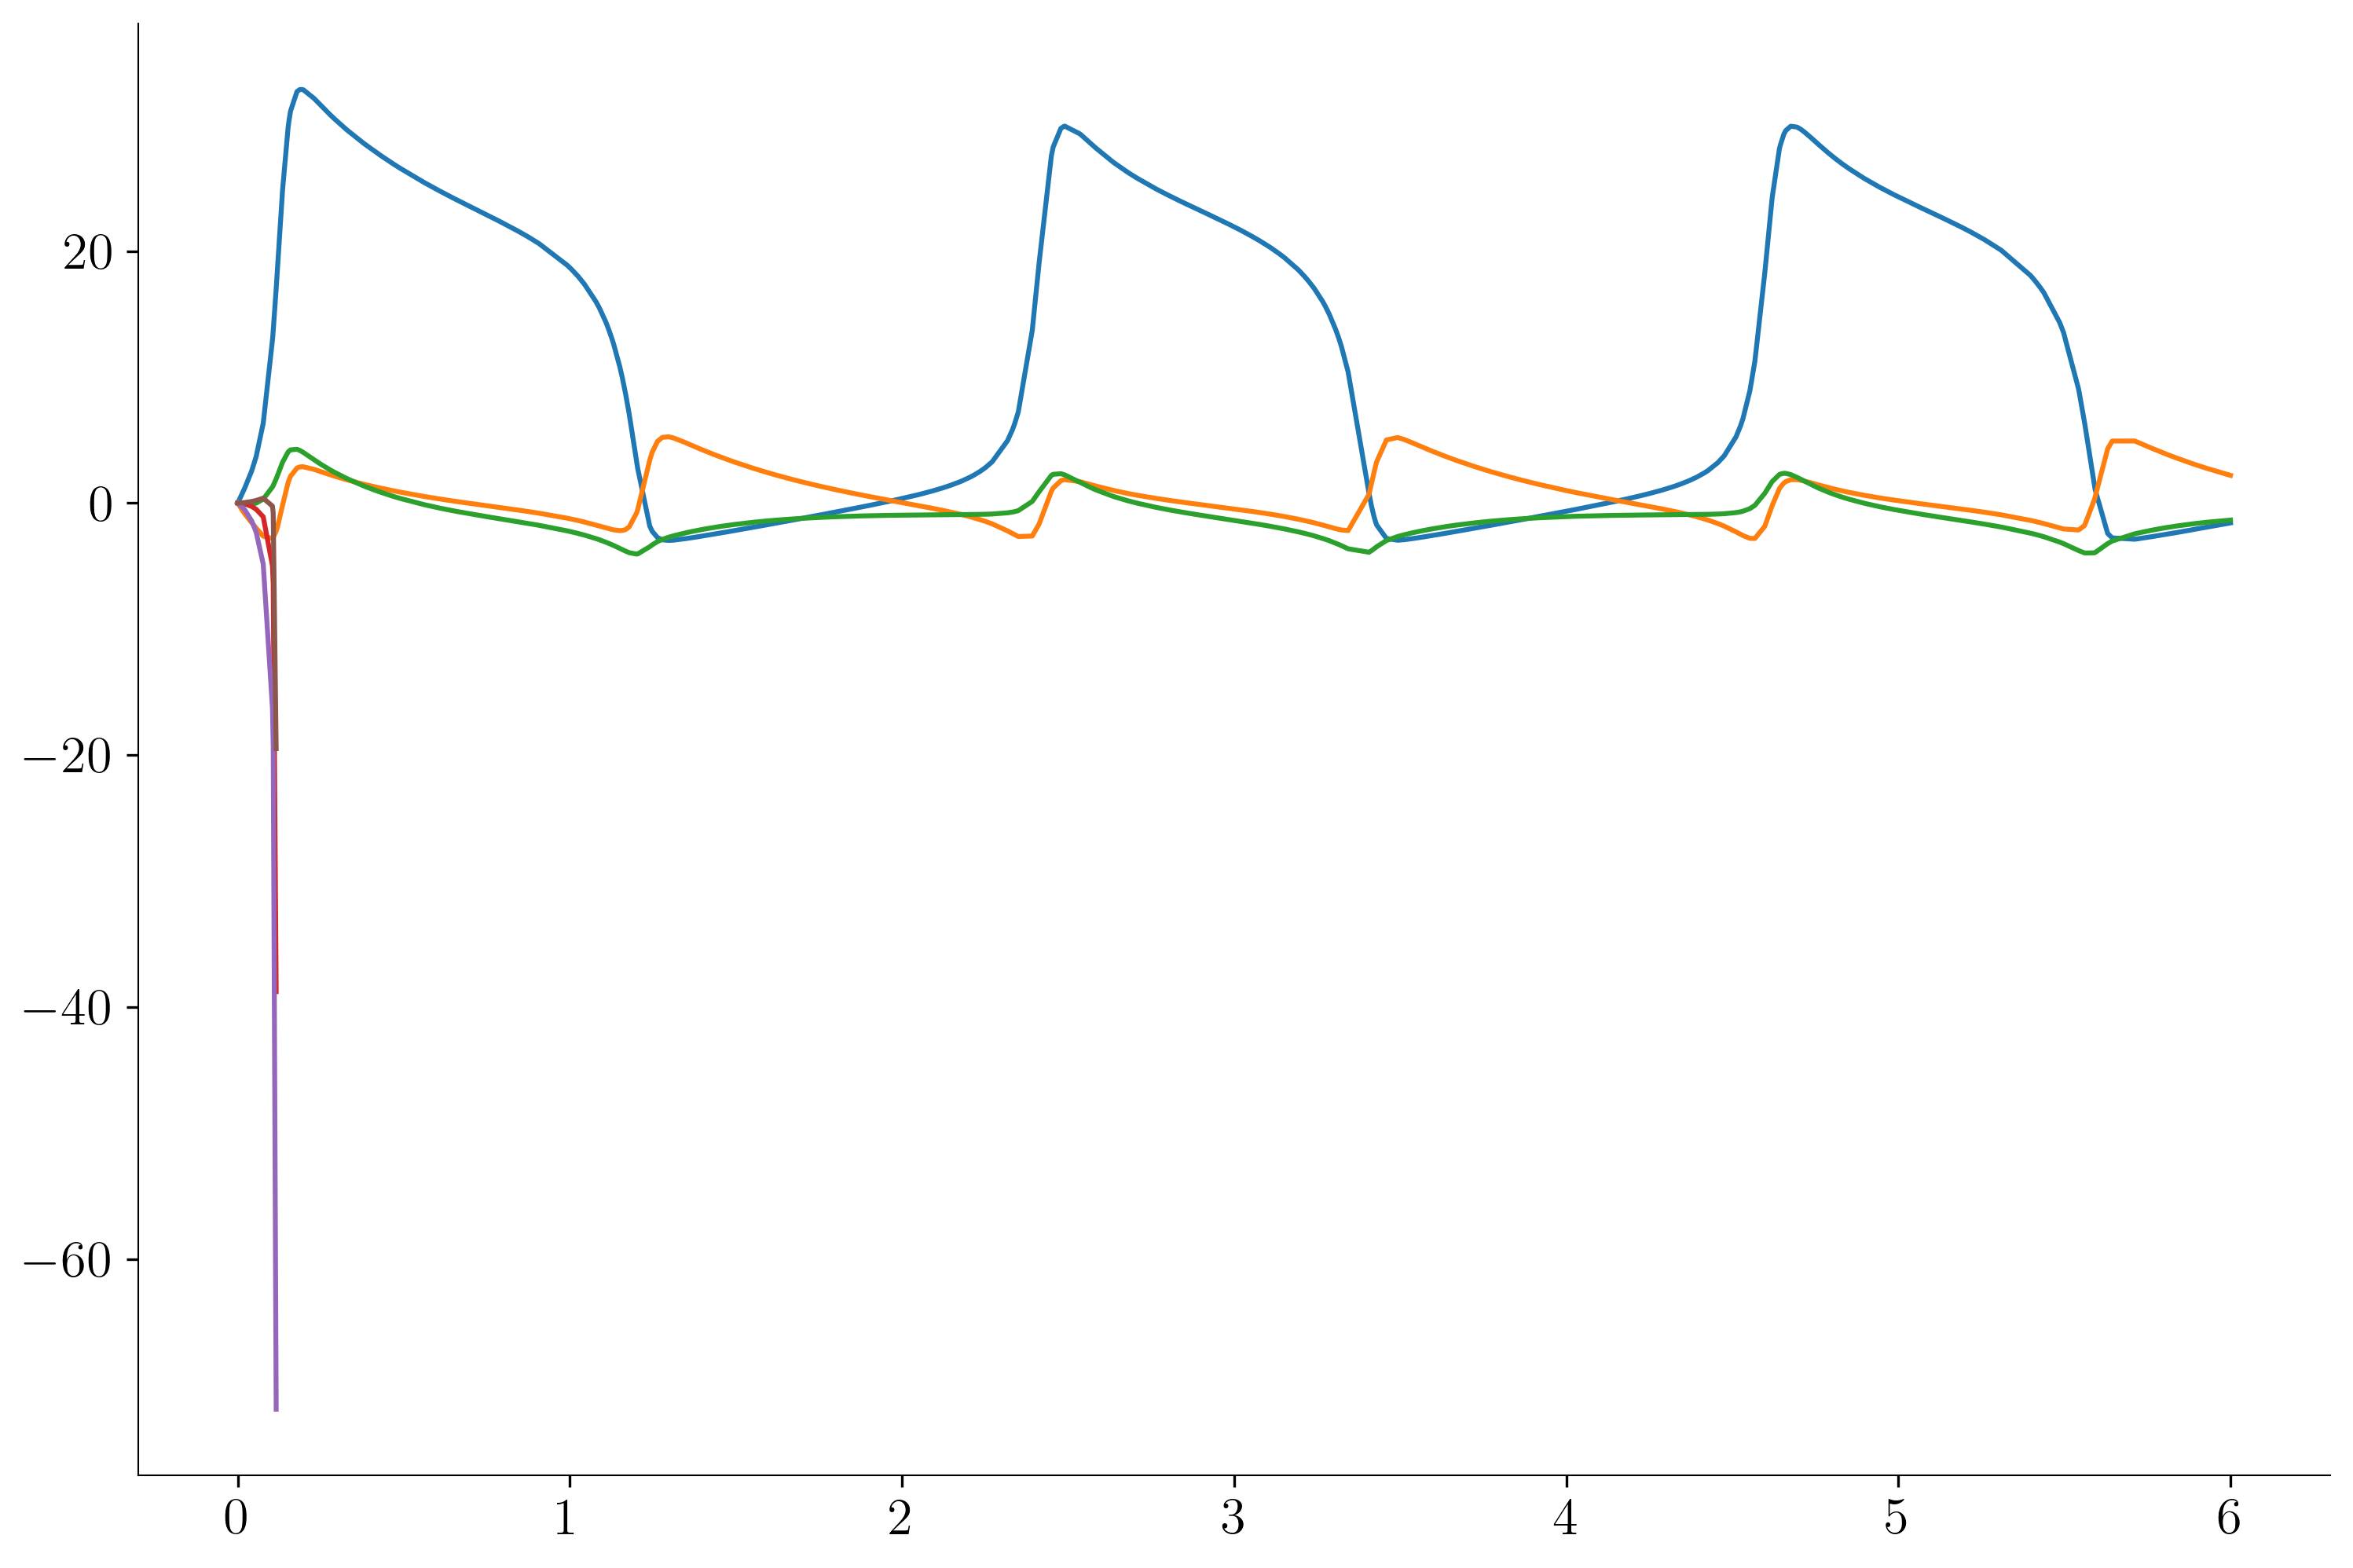

In [22]:
plt.plot(deter_sol.t, deter_pred.T)
plt.plot(custom_sol.t, custom_pred.T)